In [1]:
import sys, os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scripts.run_season import run_season

fans, events_history, score_history, snapshots = run_season(
    n_fans=300,
    n_planted_churn=25,
    decline_start_week=6,
    n_weeks=18,
    output_dir="data/weekly_snapshots",
    seed=42,
)

Matplotlib is building the font cache; this may take a moment.


In [3]:
print(fans.shape)
print(fans["is_planted_churn"].sum())
print(events_history.shape)
fans.head()

(300, 6)
25
(5400, 5)


,fan_id,tenure_years,plan_tier,baseline_engagement,is_planted_churn,decline_start_week
0,1,18,standard,0.424548,False,NaN
1,2,2,premium,0.527589,False,NaN
2,3,9,standard,0.637180,False,NaN
3,4,5,club,0.517255,False,NaN
4,5,3,standard,0.681351,False,NaN


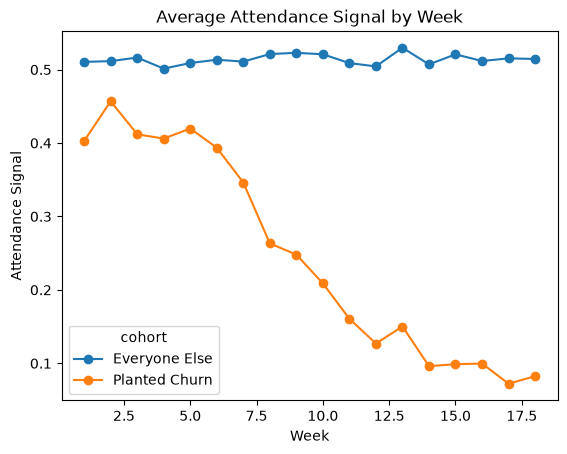

In [4]:
planted_ids = fans.loc[fans["is_planted_churn"], "fan_id"]
tagged = events_history.copy()
tagged["cohort"] = tagged["fan_id"].isin(planted_ids).map({True: "Planted Churn", False: "Everyone Else"})
trend = tagged.groupby(["week", "cohort"])["attendance_signal"].mean().unstack()

trend.plot(marker="o")
plt.title("Average Attendance Signal by Week")
plt.xlabel("Week")
plt.ylabel("Attendance Signal")
plt.show()